In [1]:
# importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('Indian-Resturants.csv')

In [3]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [4]:
df.shape

(211944, 26)

In [5]:
# duplicates
print('Number of duplicated values present: ',df.duplicated().sum())
df.drop_duplicates(inplace=True)
print('Number of duplicated values after dropping them: ',df.duplicated().sum())

Number of duplicated values present:  151527
Number of duplicated values after dropping them:  0


In [6]:
df.shape

(60417, 26)

In [7]:
# completeness

df.isnull().sum()[df.isnull().sum()>0]

address                 18
zipcode              47869
cuisines               470
timings               1070
opentable_support       19
dtype: int64

In [8]:
pd.set_option('display.max_columns',None)
df.head()

,res_id,name,establishment,url,address,city,city_id,locality,latitude,longitude,zipcode,country_id,locality_verbose,cuisines,timings,average_cost_for_two,price_range,currency,highlights,aggregate_rating,rating_text,votes,photo_count,opentable_support,delivery,takeaway
0,3400299,Bikanervala,['Quick Bites'],https://www.zomato.com/agra/bikanervala-khanda...,"Kalyani Point, Near Tulsi Cinema, Bypass Road,...",Agra,34,Khandari,27.211450,78.002381,NaN,1,"Khandari, Agra","North Indian, South Indian, Mithai, Street Foo...",8:30am – 10:30pm (Mon-Sun),700,2,Rs.,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,Very Good,814,154,0.0,-1,-1
1,3400005,Mama Chicken Mama Franky House,['Quick Bites'],https://www.zomato.com/agra/mama-chicken-mama-...,"Main Market, Sadar Bazaar, Agra Cantt, Agra",Agra,34,Agra Cantt,27.160569,78.011583,282001.0,1,"Agra Cantt, Agra","North Indian, Mughlai, Rolls, Chinese, Fast Fo...","12:30PM to 12Midnight (Mon, Wed, Thu, Fri, Sat...",600,2,Rs.,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,Very Good,1203,161,0.0,-1,-1
2,3401013,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-2-sh...,"62/1, Near Easy Day, West Shivaji Nagar, Goalp...",Agra,34,Shahganj,27.182938,77.979684,282010.0,1,"Shahganj, Agra","Fast Food, Mithai",9:30 AM to 11 PM,300,1,Rs.,"['No Alcohol Available', 'Dinner', 'Takeaway A...",4.2,Very Good,801,107,0.0,1,-1
3,3400290,Bhagat Halwai,['Quick Bites'],https://www.zomato.com/agra/bhagat-halwai-civi...,"Near Anjana Cinema, Nehru Nagar, Civil Lines, ...",Agra,34,Civil Lines,27.205668,78.004799,282002.0,1,"Civil Lines, Agra","Desserts, Bakery, Fast Food, South Indian",8am – 11pm (Mon-Sun),300,1,Rs.,"['Takeaway Available', 'Credit Card', 'Lunch',...",4.3,Very Good,693,157,0.0,1,-1
4,3401744,The Salt Cafe Kitchen & Bar,['Casual Dining'],https://www.zomato.com/agra/the-salt-cafe-kitc...,"1C,3rd Floor, Fatehabad Road, Tajganj, Agra",Agra,34,Tajganj,27.157709,78.052421,NaN,1,"Tajganj, Agra","North Indian, Continental, Italian",11:30 AM to 11:30 PM,1000,3,Rs.,"['Lunch', 'Serves Alcohol', 'Cash', 'Credit Ca...",4.9,Excellent,470,291,0.0,1,-1


In [9]:
#dropping res_id, url, address, city_id, zipcode, country_id, locality_verbose, opentable_support, takeaway

### **Dropped Columns**

* **res_id** --> Unique identifier with no analytical value or correlation with other columns.
* **url** --> Long text field that does not contribute to analysis.
* **address** --> Too specific for grouping; locality and city already provide location insights.
* **city_id** --> Redundant location identifier with many missing values.
* **zipcode** --> Contains many missing values and offers limited analytical use.
* **locality_verbose** --> Duplicate combination of locality and city information.
* **opentable_support** --> Mostly contains 0 or NaN values with little variation.
* **takeaway** --> Filled with -1 placeholders and already represented in highlights column.
* **country_id** --> Only one country (India) present, so no variability.
* **currency** --> All values are in Rs, making the column constant.
* **rating_text** --> Redundant with aggregate_rating and contains noisy multilingual labels.
* **timings** --> Messy and unstructured text, difficult to analyze effectively.

### **Summary**

These columns were removed to improve dataset quality by eliminating redundant, irrelevant, constant, missing, and unstructured features.


In [10]:
df.columns

Index(['res_id', 'name', 'establishment', 'url', 'address', 'city', 'city_id',
       'locality', 'latitude', 'longitude', 'zipcode', 'country_id',
       'locality_verbose', 'cuisines', 'timings', 'average_cost_for_two',
       'price_range', 'currency', 'highlights', 'aggregate_rating',
       'rating_text', 'votes', 'photo_count', 'opentable_support', 'delivery',
       'takeaway'],
      dtype='object')

In [11]:
df.drop(['res_id','url','address','city_id','zipcode','locality_verbose','opentable_support','takeaway','country_id','currency','rating_text','timings'],axis=1,inplace=True)

In [12]:
df.shape

(60417, 14)

In [13]:
df.columns

Index(['name', 'establishment', 'city', 'locality', 'latitude', 'longitude',
       'cuisines', 'average_cost_for_two', 'price_range', 'highlights',
       'aggregate_rating', 'votes', 'photo_count', 'delivery'],
      dtype='object')

In [14]:
# seeking info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 60417 entries, 0 to 211942
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  60417 non-null  object 
 1   establishment         60417 non-null  object 
 2   city                  60417 non-null  object 
 3   locality              60417 non-null  object 
 4   latitude              60417 non-null  float64
 5   longitude             60417 non-null  float64
 6   cuisines              59947 non-null  object 
 7   average_cost_for_two  60417 non-null  int64  
 8   price_range           60417 non-null  int64  
 9   highlights            60417 non-null  object 
 10  aggregate_rating      60417 non-null  float64
 11  votes                 60417 non-null  int64  
 12  photo_count           60417 non-null  int64  
 13  delivery              60417 non-null  int64  
dtypes: float64(3), int64(5), object(6)
memory usage: 6.9+ MB


## zomato dataset overview
- the dataset contains 60417 rows and 16 columns after preprocessing.
- initially there were 211944 rows and 26, 151527 duplicates and 10 columns due to low analytical values were dropped
- it contains 3 float , 5 integer and 8 object data type columns
- The dataset contains **missing values**, which require appropriate handling through imputation or removal.
- EDA is mainly focused on key variables like ratings, cost, cuisines, and location for meaningful insights.
  
## One-line Summary
The dataset is large, mixed in data types, and requires cleaning and focused analysis on key columns to generate useful insights.

In [15]:
# seeking description

df.describe()

,latitude,longitude,average_cost_for_two,price_range,aggregate_rating,votes,photo_count,delivery
count,60417.000000,60417.000000,60417.000000,60417.000000,60417.000000,60417.000000,60417.000000,60417.000000
mean,21.349431,76.588040,538.304517,1.730821,3.032868,261.574888,194.247414,-0.371799
std,41.187998,10.600514,593.852227,0.880462,1.440751,728.284194,705.682451,0.925249
min,0.000000,0.000000,0.000000,1.000000,0.000000,-18.000000,0.000000,-1.000000
25%,16.324755,74.654029,200.000000,1.000000,2.900000,7.000000,1.000000,-1.000000
50%,22.320884,77.135310,400.000000,1.000000,3.500000,42.000000,11.000000,-1.000000
75%,26.744389,79.928190,600.000000,2.000000,4.000000,207.000000,82.000000,1.000000
max,10000.000000,91.832769,30000.000000,4.000000,4.900000,42539.000000,17702.000000,1.000000


## Insights

- **latitude**: The 10,000 max latitude is a geographical impossibility (since the scale stops at 90°), proving the column contains "junk" data that will break any map visualizations if not filtered out.
- **longitude**: The longitude column, while appearing mostly normal with an average of 76.6°, contains a minimum value of 0.0 that likely represents missing location data (placing restaurants in the ocean) rather than actual restaurant coordinates.
- **average_cost_for_two**: the minimum cost is 0 which indicates missing data that should be handled and the maximum cost 30000 indicates that we have some ulta-expensive restaurants
- **price_range**: mean(1.73) inidcates that most of the data fall on the lower end of cost spectrum, half of the restaurants(50%) are at Level 1 (budget), 75th percentile is only levle 2, level 3 and level 4 ('luxury' or 'high-end') are quite rare in the dataset
- **aggregate_rating**: the avg rating is 3.03,the 25th percentile is 2.9, it shows that a large chunk of  data consists of "average" rated places. several restaurants have 0 rating, yhis usually mean they are new or unrated not necessarily terrible. A full quarter of your restaurants are rated 4.0 or higher.
The data is slightly "top-heavy"—once a restaurant gets rated, it tends to be rated well (between 3.5 and 4.0)
- **votes**: min is -18, votes can never be in minus, there is a massive populairty ga[p, where most restaurants have fewer than 42 votes and few viral outliers with upto 42539 votes heavliy inflated the average.
- **photo_count**: max value reaches 17702 which is a heavy outlier. the mean is being heavily skewed by a few outliers containing extremely popular "Instagrammable" spots, while the vast majority of restaurants have very little visual content.
- **delivery**: The column shows that while at least 25%(75th percentile) of restaurants offer the service (value 1), more than half the data is currently obscured by -1 placeholders, representing missing or unknown information.

In [16]:
# completeness

df.isnull().sum()[df.isnull().sum()>0]

cuisines    470
dtype: int64

In [17]:
df.isnull().mean()[df.isnull().mean()>0]*100

cuisines    0.777927
dtype: float64

In [18]:
df.dropna(inplace=True)

* **More than half of the null values** were automatically removed after dropping insignificant and low-value columns.
* The **mean proportion of remaining null values** was very small, so dropping those rows had minimal impact on the overall dataset.
* Removing these null values helps maintain **data integrity** and improves dataset consistency.
* It also prevents **biased or skewed analysis** caused by incomplete records.
* A cleaner dataset ensures **more accurate insights and better visualizations** during EDA.

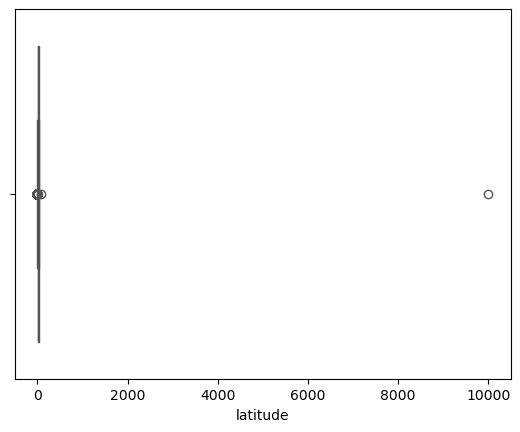

In [19]:
# latitude

sns.boxplot(data=df,x='latitude',color='#E23744')
plt.show()

India is geographically located between approximately **8°N and 37°N** latitude. Therefore, values outside this range are likely incorrect for an India-only dataset.

* **Minimum Latitude:** ~8°N (Southern tip near Kanyakumari)
* **Maximum Latitude:** ~37°N (Northernmost regions in Jammu & Kashmir / Ladakh)

In [20]:
df = df[(df['latitude'] >= 8) & (df['latitude'] <= 37)]

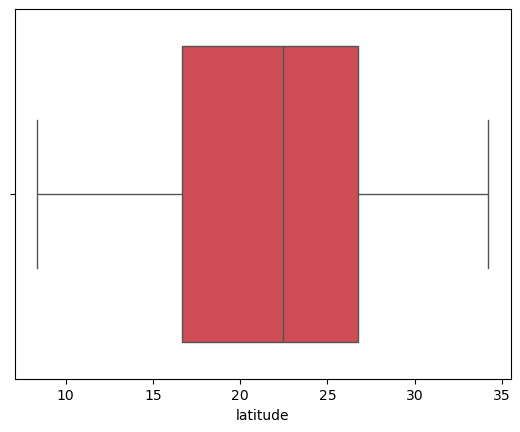

In [21]:
sns.boxplot(data=df,x='latitude',color='#E23744')
plt.show()

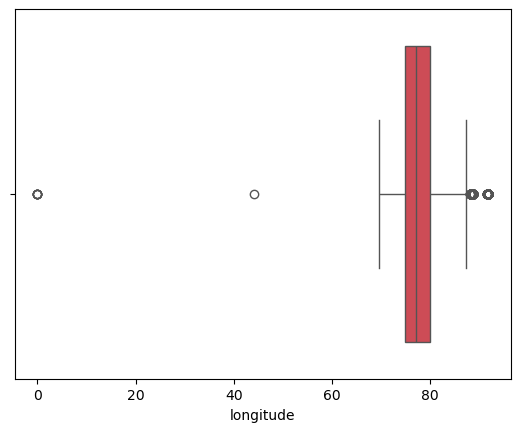

In [22]:
# longitude

sns.boxplot(data=df,x='longitude',color='#E23744')
plt.show()

India is geographically located between approximately **68°E and 97°E** longitude. Therefore, values outside this range are likely incorrect for an India-only dataset.

* **Minimum Longitude:** ~68°E (Western Gujarat)
* **Maximum Longitude:** ~97°E (Eastern Arunachal Pradesh)

In [23]:
df = df[(df['longitude'] >= 68) & (df['longitude'] <= 97)]

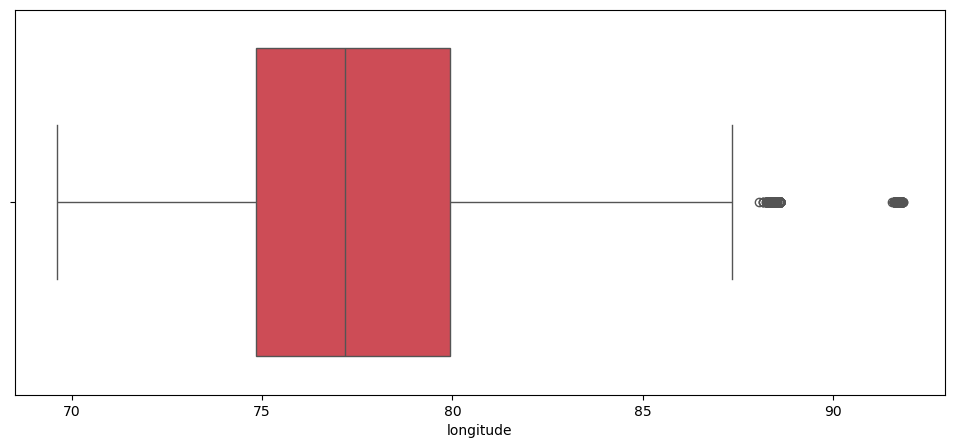

In [24]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='longitude',color='#E23744')
plt.show()

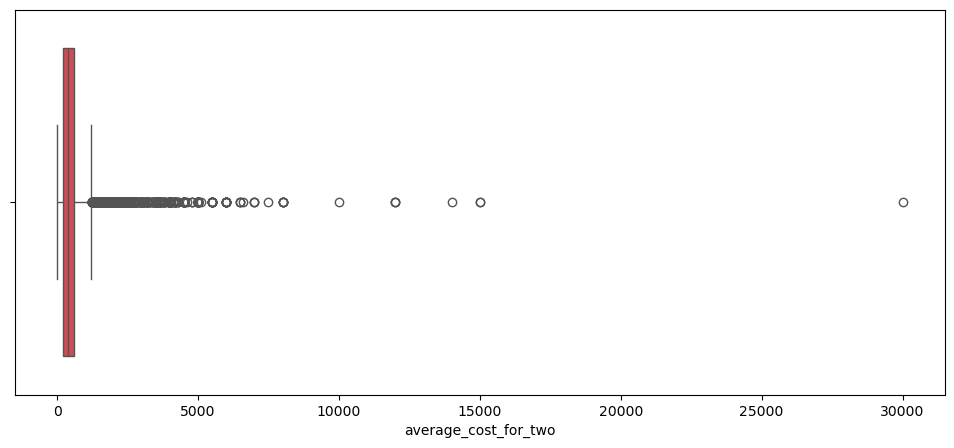

In [25]:
# average_cost_for_two

plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='average_cost_for_two',color='#E23744')
plt.show()

Since the average cost for two cannot be 0, those invalid values were replaced with the median, as it is less affected by outliers and provides a more reliable estimate.

In [26]:
df.average_cost_for_two = df.average_cost_for_two.replace(0,df.average_cost_for_two.median())

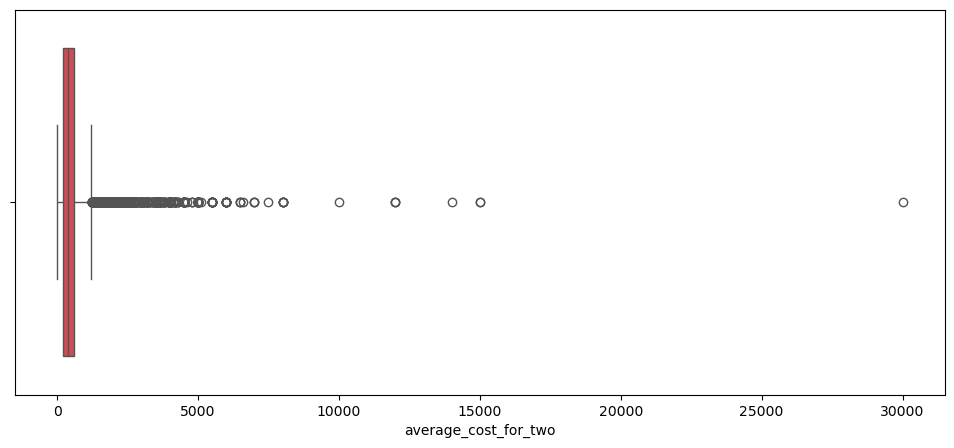

In [27]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='average_cost_for_two',color='#E23744')
plt.show()

In [28]:
df[df['average_cost_for_two'] > 25000]

,name,establishment,city,locality,latitude,longitude,cuisines,average_cost_for_two,price_range,highlights,aggregate_rating,votes,photo_count,delivery
136240,Ocean - The Private Dining Room - Sahara Star,['Fine Dining'],Mumbai,"Sahara Star, Vile Parle East",19.094752,72.854226,"Asian, Seafood, North Indian, Mediterranean",30000,4,"['Dinner', 'Serves Alcohol', 'Debit Card', 'Ca...",3.6,91,31,-1


It is a legitimate entry for a high-end private dining experience at a 5-star hotel in Mumbai where exclusivity and ambiance, rather than just food, drive the extreme price.

In [29]:
df.average_cost_for_two.min()

2

In [30]:
df.average_cost_for_two.median()

400.0

2 as the average cost for two persons is impossible. replacing everything under 100 to make data look realistic.

In [31]:
df.loc[df['average_cost_for_two'] < 100, 'average_cost_for_two'] = df['average_cost_for_two'].median()

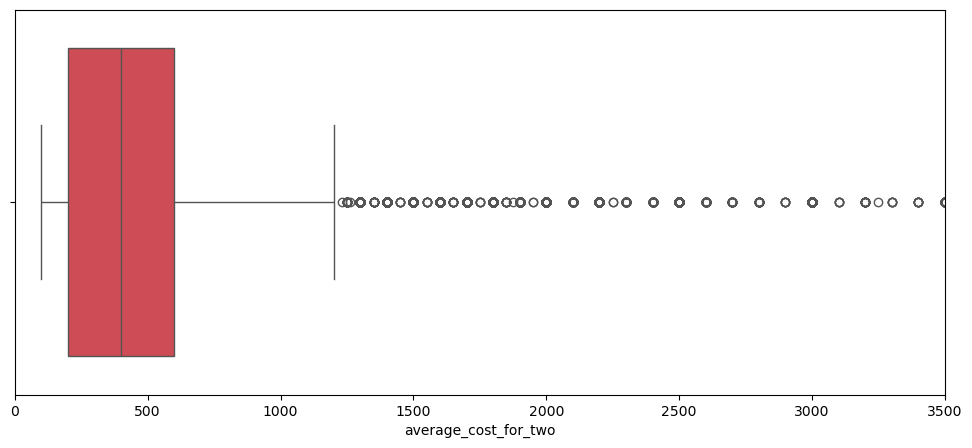

In [32]:
# zoomed view
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='average_cost_for_two',color='#E23744')
plt.xlim(0, 3500)
plt.show()

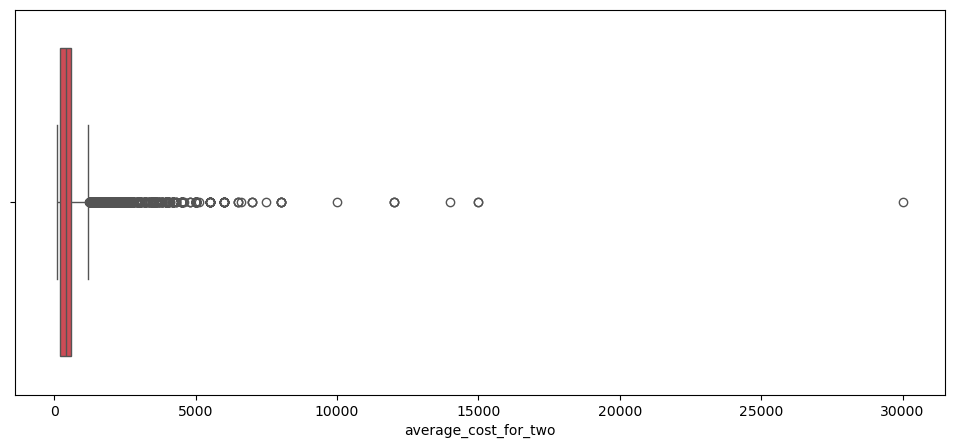

In [33]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='average_cost_for_two',color='#E23744')
plt.show()

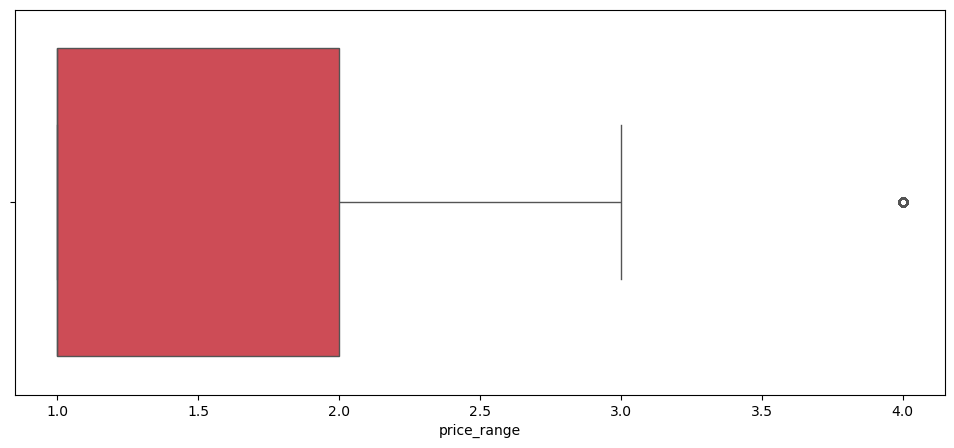

In [34]:
# price_range
plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='price_range',color='#E23744')
plt.show()

In [35]:
df.columns

Index(['name', 'establishment', 'city', 'locality', 'latitude', 'longitude',
       'cuisines', 'average_cost_for_two', 'price_range', 'highlights',
       'aggregate_rating', 'votes', 'photo_count', 'delivery'],
      dtype='object')

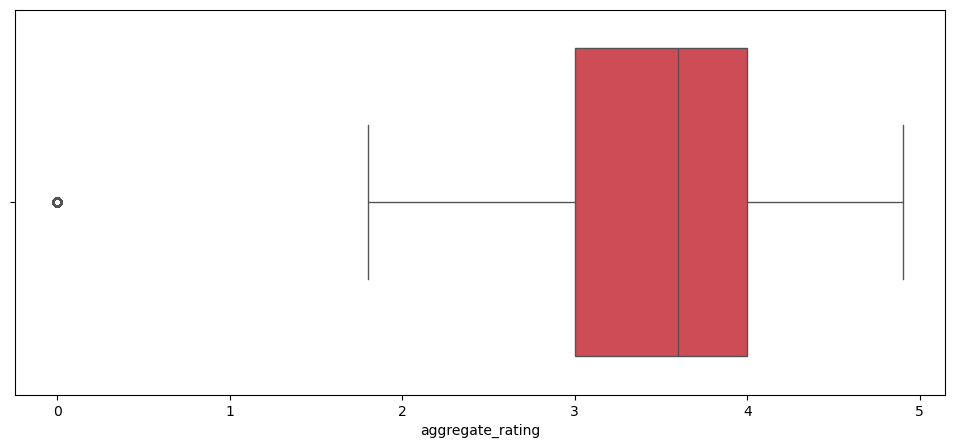

In [36]:
# aggregate_rating

plt.figure(figsize=(12,5))
sns.boxplot(data=df,x='aggregate_rating',color='#E23744')
plt.show()

In [37]:
df['aggregate_rating'].value_counts().head()

aggregate_rating
0.0    9266
3.9    3955
3.8    3825
4.0    3813
3.7    3640
Name: count, dtype: int64

* **0.0 ratings were treated as null values in disguise**, as they usually represent **new restaurants or no reviews**, not poor quality.
* These **0 ratings pull the mean downward**, making the restaurant scene appear worse than it actually is.
* Mixing unrated restaurants with genuinely rated ones reduces the **accuracy of customer experience analysis**.
* To understand real customer sentiment, only restaurants with valid ratings should be considered.
* A **filtered boxplot excluding 0 ratings** can be used to visualize the true distribution of customer opinions.


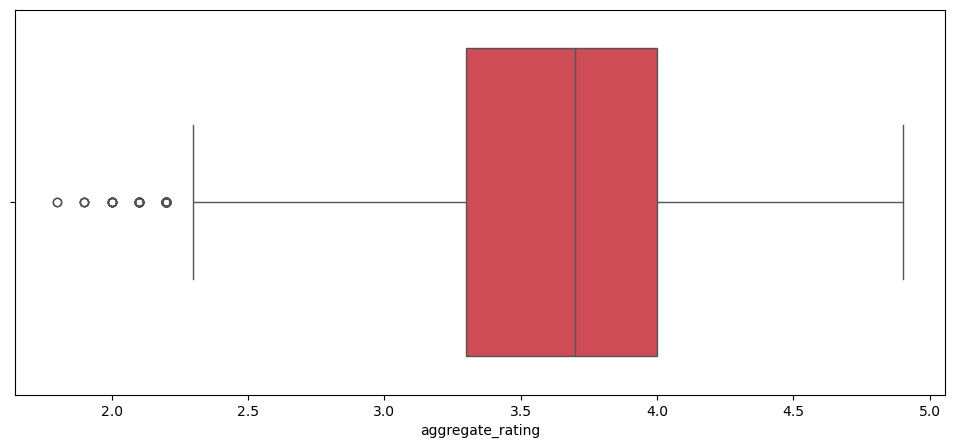

In [38]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['aggregate_rating'] > 0], x='aggregate_rating',color='#E23744')
plt.show()

In [39]:
# votes

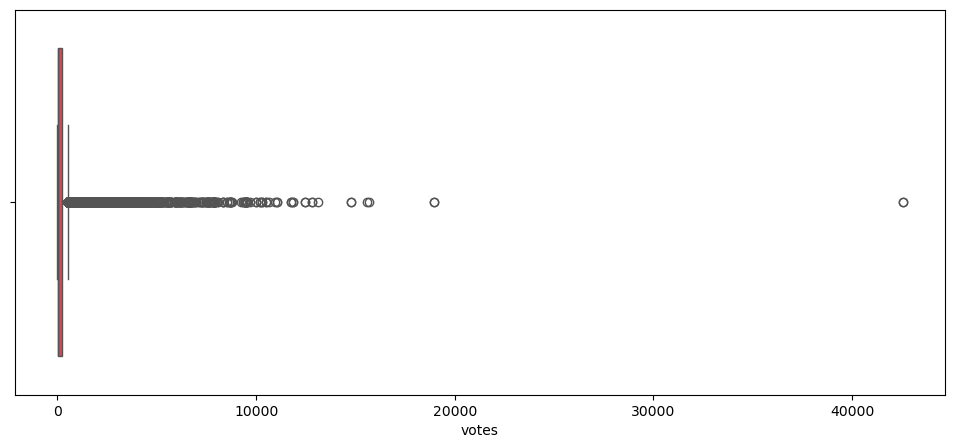

In [40]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='votes',color='#E23744')
plt.show()

In [41]:
df[df.votes<0]

,name,establishment,city,locality,latitude,longitude,cuisines,average_cost_for_two,price_range,highlights,aggregate_rating,votes,photo_count,delivery
989,Vaishno The Cake Makers,['Bakery'],Agra,Khandari,27.205886,77.998236,"Desserts, Burger, Sandwich",250,1,"['Takeaway Available', 'Debit Card', 'Cash', '...",3.7,-18,15,1
101364,Parihar Fast Food & Restaurant,['Casual Dining'],Jodhpur,Maderana Colony,26.319121,73.057794,Fast Food,150,1,"['Takeaway Available', 'Delivery', 'Cash', 'In...",2.8,-3,3,-1


- votes can never be negative, these negative entries are errors, so turning them into zero

In [42]:
df.loc[df['votes']<0,'votes'] = 0

* It is possible for a restaurant to have a **0 rating**, usually because it is new or has not received enough reviews yet.
* For identifying the **best restaurants**, it is better to filter places with minimum social proof, such as more than **10 or 50 votes**.
* Including **0 ratings/votes** in correlation studies can distort results, so they should be excluded during analysis rather than deleted permanently.
* Restaurants with **40,000+ votes** act as extreme outliers and compress the boxplot scale.
* To view the actual vote distribution clearly, a **zoomed-in boxplot** should be used since most restaurants have fewer than **100 votes**.


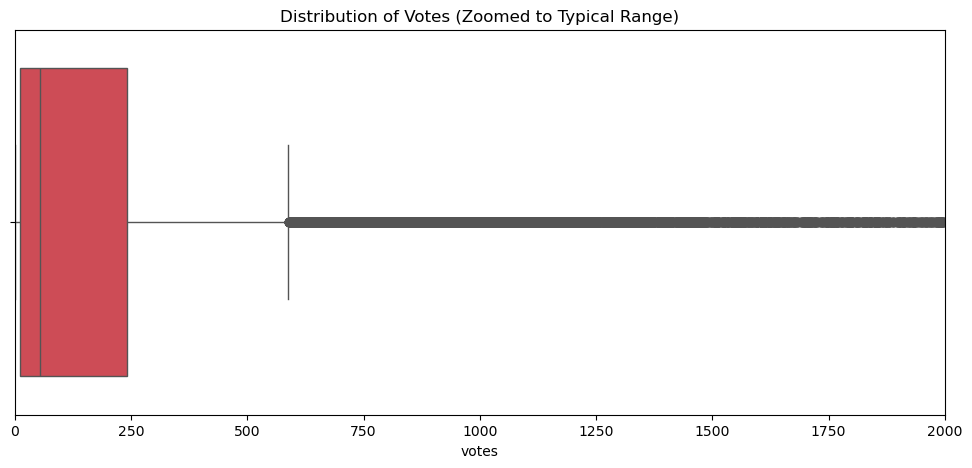

In [43]:
plt.figure(figsize=(12,5))
sns.boxplot(data=df[df['votes']>0], x='votes',color='#E23744')
plt.xlim(0,2000)
plt.title('Distribution of Votes (Zoomed to Typical Range)')
plt.show()

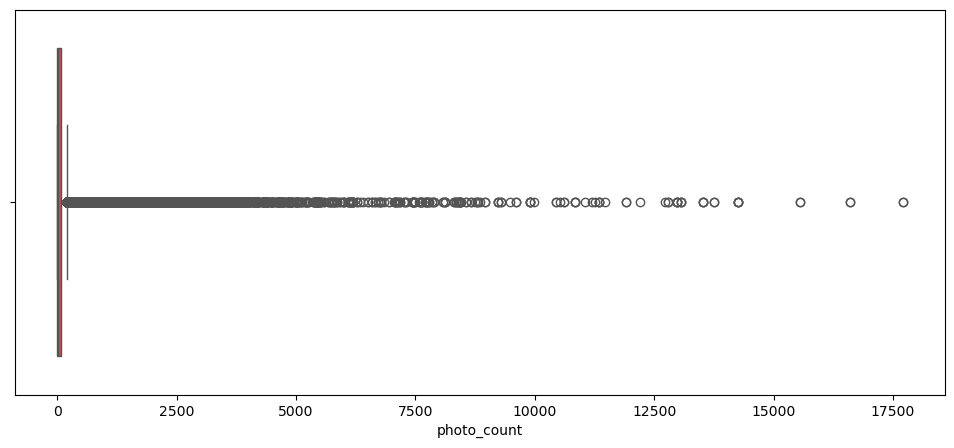

In [44]:
# photo_count

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='photo_count',color='#E23744')
plt.show()

In [45]:
df.nlargest(5, 'photo_count')[['name', 'city', 'photo_count']]

,name,city,photo_count
53925,Prankster,Gurgaon,17702
55439,Prankster,Gurgaon,17702
134855,Tamasha,Mumbai,16595
140261,Tamasha,Mumbai,16595
54209,38 Barracks,New Delhi,15545


* A new **capped votes column** was created by limiting values at **500** to reduce the effect of extreme outliers.
* This prevents restaurants with very high vote counts (such as **17,000+**) from compressing chart scales.
* Capping helps produce clearer and more interpretable visualizations for EDA.


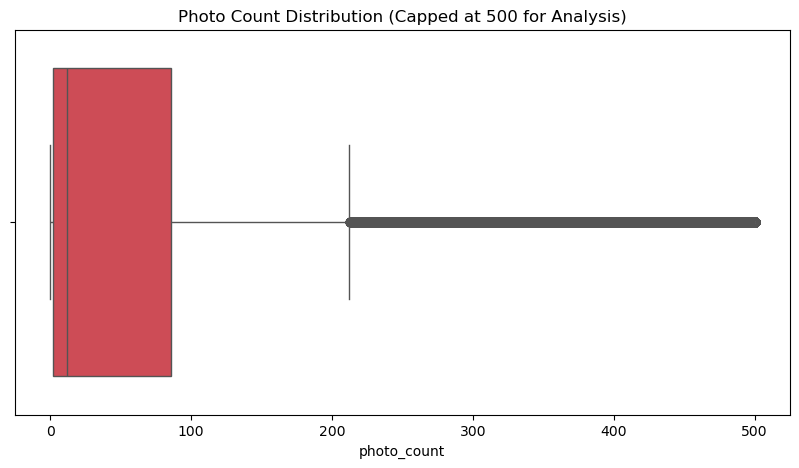

In [46]:
df['photo_count'].clip(upper=500)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x=df['photo_count'].clip(upper=500), color='#E23744')
plt.title('Photo Count Distribution (Capped at 500 for Analysis)')
plt.show()

In [47]:
# delivery 

df.loc[df['delivery'] == -1, 'delivery'] = 0

df['delivery'] = df['delivery'].astype(int)

print("Unique values now:", df['delivery'].unique())

Unique values now: [0 1]


* In the **delivery column**, values likely represent a binary indicator where **1 = Available** and **0 = Not Available**.
* Therefore, **-1 values** were identified as data entry errors or placeholders for missing information.
* For preprocessing, these **-1 values were replaced with 0**, assuming the service is likely not offered when status is unknown.
* This follows standard practice and ensures cleaner binary data for analysis.


In [48]:
df.head(2)

,name,establishment,city,locality,latitude,longitude,cuisines,average_cost_for_two,price_range,highlights,aggregate_rating,votes,photo_count,delivery
0,Bikanervala,['Quick Bites'],Agra,Khandari,27.211450,78.002381,"North Indian, South Indian, Mithai, Street Foo...",700,2,"['Lunch', 'Takeaway Available', 'Credit Card',...",4.4,814,154,0
1,Mama Chicken Mama Franky House,['Quick Bites'],Agra,Agra Cantt,27.160569,78.011583,"North Indian, Mughlai, Rolls, Chinese, Fast Fo...",600,2,"['Delivery', 'No Alcohol Available', 'Dinner',...",4.4,1203,161,0


In [49]:
# cuisines

In [50]:
df['primary_cuisine'] = df['cuisines'].str.split(',',expand=True)[0]

* A new **Primary Cuisine** column was created by extracting the **first cuisine listed** for each restaurant.
* The first listed cuisine is usually considered the restaurant’s **main specialty or primary offering**.
* This simplifies multi-cuisine entries and makes cuisine-based EDA more clear and effective.

In [51]:
df.primary_cuisine.value_counts().head(10)

primary_cuisine
North Indian    13748
Fast Food        4496
Bakery           3904
Cafe             3608
South Indian     3584
Chinese          3007
Desserts         2655
Beverages        2511
Mithai           2481
Street Food      1828
Name: count, dtype: int64

# EDA

## Univariate analysis

In [52]:
df.columns

Index(['name', 'establishment', 'city', 'locality', 'latitude', 'longitude',
       'cuisines', 'average_cost_for_two', 'price_range', 'highlights',
       'aggregate_rating', 'votes', 'photo_count', 'delivery',
       'primary_cuisine'],
      dtype='object')

In [53]:
# cuisines
# top 10 cuisines
top_10_data = df.primary_cuisine.value_counts().head(10).reset_index()
top_10_data

,primary_cuisine,count
0,North Indian,13748
1,Fast Food,4496
2,Bakery,3904
3,Cafe,3608
4,South Indian,3584
5,Chinese,3007
6,Desserts,2655
7,Beverages,2511
8,Mithai,2481
9,Street Food,1828


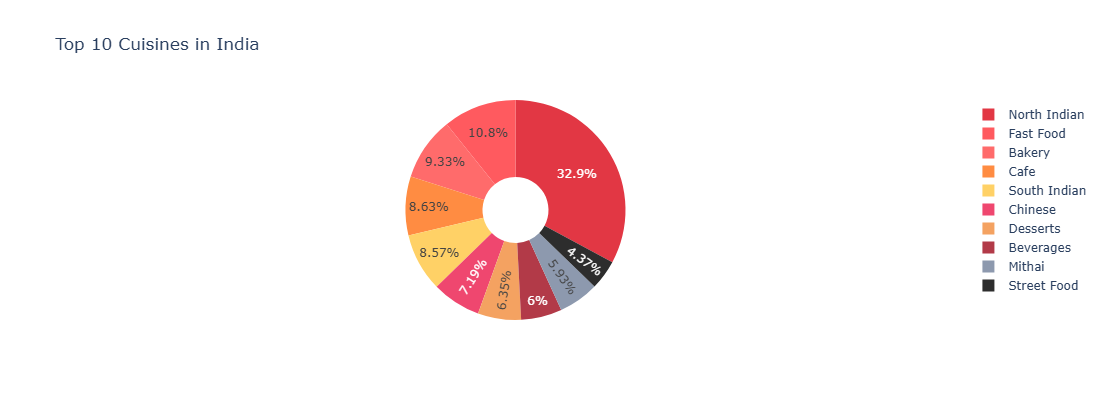

In [54]:
palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C42', '#FFD166', '#EF476F', '#F4A261', '#B23A48', '#8D99AE', '#2D2D2D']
px.pie(top_10_data,values='count',names='primary_cuisine',title='Top 10 Cuisines in India',hole=.3,height=400,color_discrete_sequence=palette)


* The pie chart shows the **percentage share** of the top 10 cuisines available in the dataset.
* **North Indian cuisine dominates** with **32.9%**, indicating it is the most popular and widely offered cuisine.
* **Fast Food (10.7%)** ranks second, showing strong demand for quick-service dining.
* **Bakery (9.33%)**, **Cafe (8.63%)**, and **South Indian (8.57%)** have similar shares, reflecting balanced popularity.
* **Chinese cuisine (7.19%)** has a noticeable presence, highlighting demand for international flavors.
* **Desserts (6.35%)**, **Beverages (6.0%)**, and **Mithai (5.93%)** indicate growing preference for snack and sweet-based outlets.
* **Street Food (4.37%)** has the smallest share among the top 10 cuisines.
* Overall, the chart shows that the market is highly concentrated, with **North Indian cuisine alone covering nearly one-third** of total listings.




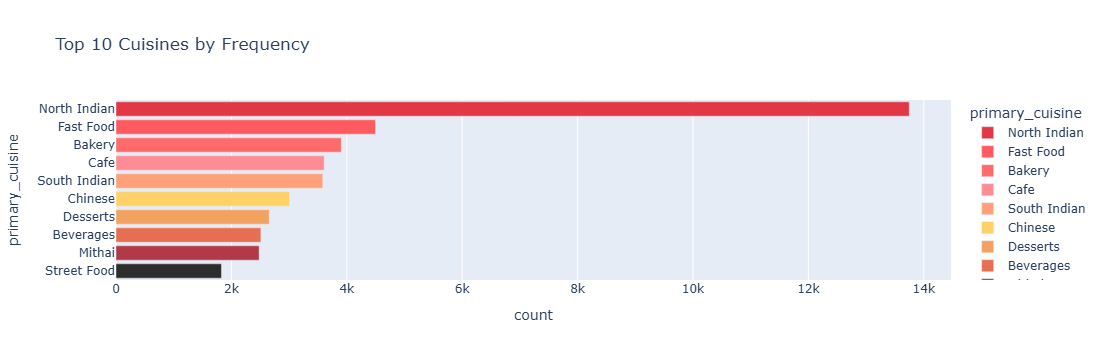

In [55]:
palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']
fig = px.bar(top_10_data,x=top_10_data['count'],y=top_10_data['primary_cuisine'],title='Top 10 Cuisines by Frequency',color='primary_cuisine',color_discrete_sequence=palette)
fig.show()

* The bar chart displays the **number of restaurants** for each of the top 10 cuisines in the dataset.
* **North Indian cuisine ranks first** with the highest count, far exceeding all other cuisines.
* **Fast Food** holds the second position, showing strong popularity among consumers.
* **Bakery, Cafe, and South Indian** have similar frequencies, indicating steady market demand.
* **Chinese cuisine** has a moderate presence compared to the leading categories.
* **Desserts, Beverages, and Mithai** follow closely, reflecting demand for sweets and drink-focused outlets.
* **Street Food** has the lowest count among the top 10 cuisines.
* Overall, the chart highlights that **North Indian cuisine dominates restaurant listings**, while the remaining cuisines are more evenly distributed.


## Insights
* Both charts confirm that **North Indian cuisine dominates the market**, holding the highest percentage share and restaurant count.
* **Fast Food** consistently ranks second, showing strong customer preference for quick and convenient dining options.
* **Bakery, Cafe, and South Indian** form the mid-tier group with similar shares and frequencies, indicating balanced demand.
* **Chinese cuisine** maintains a steady presence, reflecting popularity of international food choices.
* **Desserts, Beverages, and Mithai** show moderate representation, highlighting demand for snacks, sweets, and drinks.
* **Street Food** has the lowest share and count among the top 10 cuisines.
* The cuisine market is **highly concentrated**, with North Indian alone taking nearly one-third of total listings.
* After the top category, the remaining cuisines are relatively evenly distributed across the market.
* Consumers prefer a mix of **traditional Indian cuisines and modern fast-service options**.
* Restaurants offering **multi-cuisine menus combining North Indian, Fast Food, and Cafe items** may attract broader audiences.


In [56]:
df.columns

Index(['name', 'establishment', 'city', 'locality', 'latitude', 'longitude',
       'cuisines', 'average_cost_for_two', 'price_range', 'highlights',
       'aggregate_rating', 'votes', 'photo_count', 'delivery',
       'primary_cuisine'],
      dtype='object')

In [57]:
# ratings
# distribution of ratings

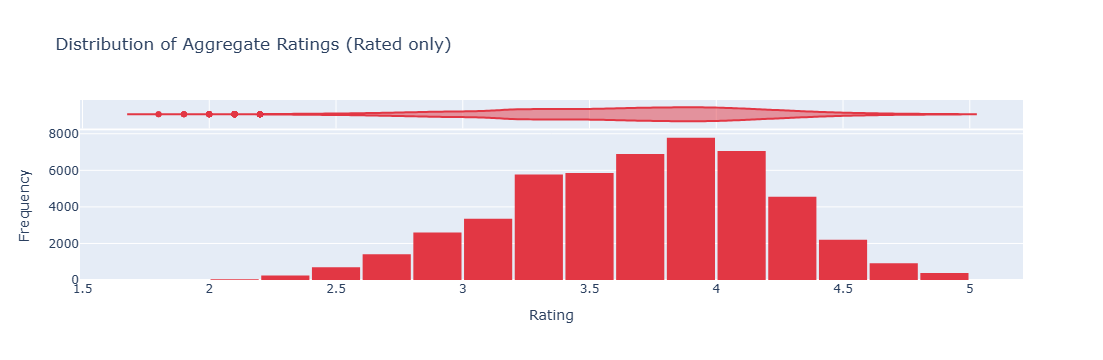

In [58]:
plot_data = df[df['aggregate_rating'] > 0]
fig = px.histogram(
    plot_data, 
    x='aggregate_rating', 
    nbins=20, 
    title='Distribution of Aggregate Ratings (Rated only)',
    color_discrete_sequence=['#E23744'],
    marginal='violin', # Adds a density rug at the bottom (Plotly's KDE alternative)
    labels={'aggregate_rating': 'Aggregate Rating'})

fig.update_layout(
    bargap=0.05, 
    xaxis_title="Rating", 
    yaxis_title="Frequency")

fig.show()


* Most restaurants are rated between **3.5 and 4.2**, indicating generally positive customer satisfaction.
* The **highest concentration is around rating 4.0**, showing many restaurants maintain good service and food quality.
* Very few restaurants have ratings **below 3.0**, which may indicate lower-quality outlets or places that are **not yet widely discovered by customers**.
* Only a small number of restaurants achieve **near-perfect ratings (4.8 to 5.0)**, making top-rated outlets relatively rare.
* The distribution is **slightly left-skewed (negative skew)**, meaning ratings are concentrated on the higher side with a tail toward lower ratings.
* This suggests customers tend to give moderate-to-good ratings rather than extreme low scores.
* Overall, the restaurant market appears **competitive with mostly above-average customer experiences**.


In [59]:
# city
# top 10 cities

Index(['city', 'count'], dtype='object')


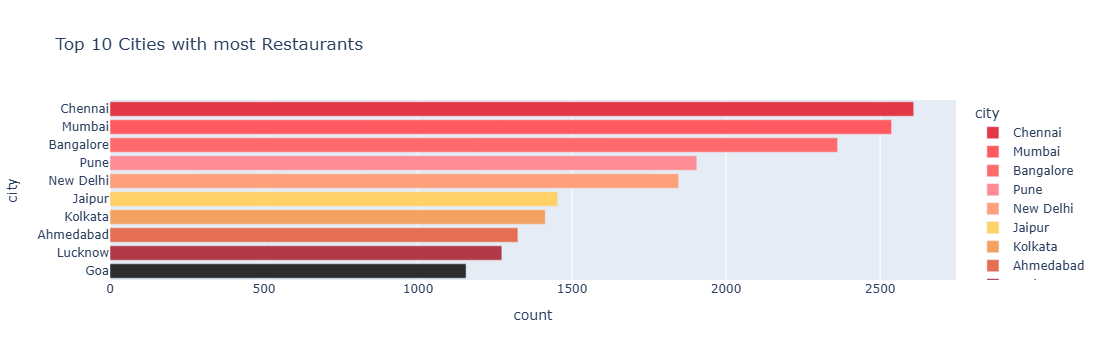

In [60]:
city_counts = df['city'].value_counts().head(10).reset_index()
print(city_counts.columns)
palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']
fig = px.bar(city_counts,x='count',y='city',title='Top 10 Cities with most Restaurants',color='city',color_discrete_sequence=palette)
fig.show()


* **Chennai ranks first** with the highest number of restaurants, indicating a strong food culture and high market presence.
* **Mumbai follows closely**, showing another major and competitive dining market with strong consumer demand.
* **Bangalore** holds third position, reflecting its growing urban population and expanding restaurant ecosystem.
* **Pune** and **New Delhi** occupy the mid-tier, suggesting steady growth and diverse food options.
* **Jaipur** and **Kolkata** show moderate restaurant counts, highlighting developing but active food markets.
* **Ahmedabad, Lucknow, and Goa** are at the lower end among the top 10, indicating comparatively smaller restaurant representation in the dataset.
* The close competition among top cities suggests that metro cities dominate India’s organized restaurant industry.
* Overall, restaurant concentration is higher in economically active and densely populated urban centers.


In [61]:
# price range
# Price Range (The "Budget" Snapshot)

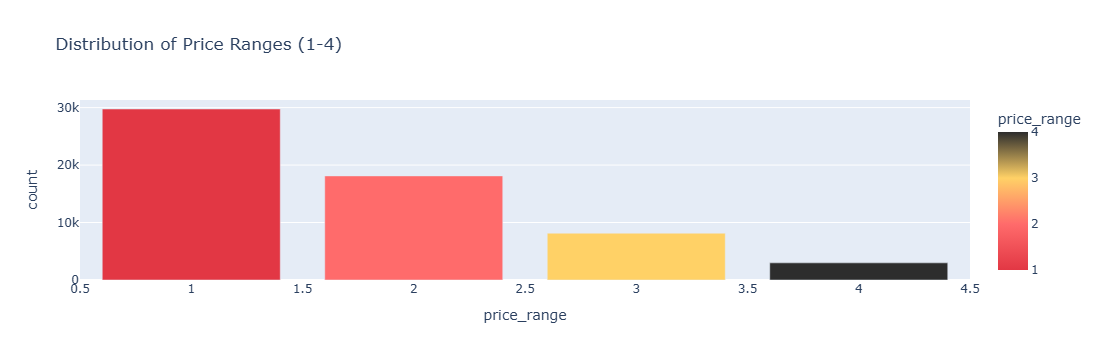

In [62]:
palette = ['#E23744', '#FF6B6B', '#FFD166', '#2D2D2D']
fig = px.bar(df['price_range'].value_counts().reset_index(),x='price_range',y='count',color='price_range',color_continuous_scale=palette,title='Distribution of Price Ranges (1-4)')
fig.show()


* **Price Range 1** has the highest number of restaurants, showing that most restaurants are budget-friendly and affordable.
* **Price Range 2** is the second most common category, indicating strong demand for moderately priced dining options.
* **Price Range 3** has significantly fewer restaurants, representing a smaller mid-premium market segment.
* **Price Range 4** has the lowest count, showing that luxury or high-end restaurants form only a small portion of the market.
* The distribution is **right-skewed**, where restaurant counts decrease as price range increases.
* This suggests that the Indian restaurant market is largely driven by **value-for-money and mass-market consumers**.
* Premium and fine-dining restaurants exist but cater to a comparatively smaller customer base.
* Overall, affordability appears to be a key factor influencing restaurant presence in the dataset.


In [63]:
# delivery

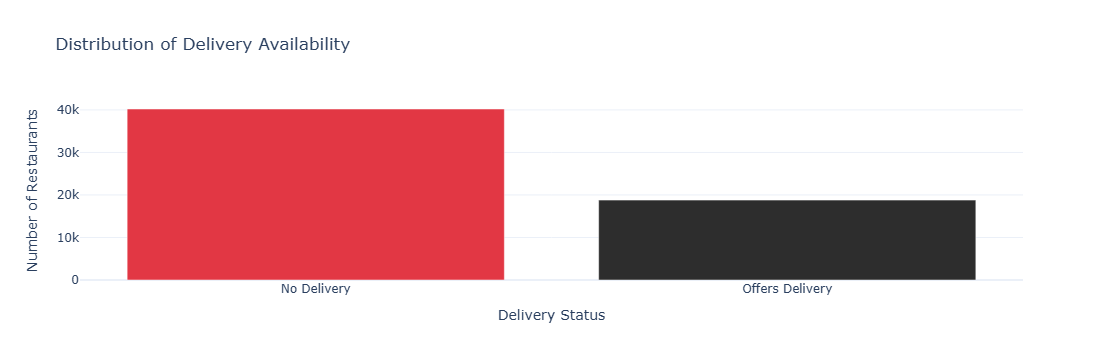

In [64]:
delivery_counts = df['delivery'].value_counts().reset_index()
delivery_counts.columns = ['delivery', 'count']

delivery_counts['delivery_label'] = delivery_counts['delivery'].map({1: 'Offers Delivery', 0: 'No Delivery'})

palette = ['#E23744', '#2D2D2D']

fig = px.bar(
    delivery_counts, 
    x='delivery_label', 
    y='count', 
    color='delivery_label',
    color_discrete_sequence=palette,
    title='Distribution of Delivery Availability',
    template='plotly_white',
    labels={'delivery_label': 'Delivery Status', 'count': 'Number of Restaurants'}
)

fig.update_layout(showlegend=False)

fig.show()

* Most restaurants have **no online delivery available**, indicating that offline dining still dominates a large part of the market.
* This may be because many small restaurants cannot yet afford the required technology, logistics, or platform commissions.
* In several regions, digital adoption is still growing, so many businesses have not fully integrated with delivery platforms like Zomato.
* Limited awareness, infrastructure gaps, and operational challenges may also contribute to lower delivery availability.
* A smaller segment of restaurants is more digitally aware and has already adopted online delivery services.
* These tech-enabled outlets are likely gaining competitive advantages through wider reach and customer convenience.
* Overall, the variation reflects the gap between traditional restaurant operations and rapidly modernizing food businesses in a developing market.


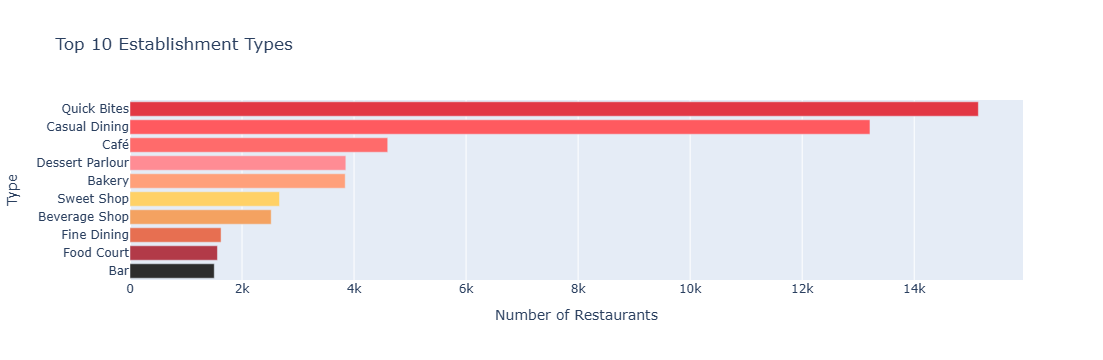

In [65]:
# establishment
# top 10 establishment

df['establishment_cleaned'] = df['establishment'].apply(
    lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x).strip("[]'")
)
df['establishment_cleaned'] = df['establishment_cleaned'].replace(['', 'nan', 'None'], np.nan)

top_establishments = df['establishment_cleaned'].value_counts().head(10).reset_index()
top_establishments.columns = ['Establishment Type', 'Count']

palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']

fig = px.bar(
    top_establishments, 
    x='Count', 
    y='Establishment Type', 
    color='Establishment Type',
    color_discrete_sequence=palette,
    title='Top 10 Establishment Types',
    labels={'Count': 'Number of Restaurants', 'Establishment Type': 'Type'}
)

fig.update_layout(yaxis={'categoryorder':'total ascending'}, showlegend=False)

fig.show()


* **Quick Bites** dominate the market, showing high demand for fast, affordable, and convenient dining options.
* **Casual Dining** and **Cafés** rank next, indicating strong preference for sit-down meals, social gatherings, and urban hangout spaces.
* Dessert-focused outlets like **Dessert Parlour, Bakery, and Sweet Shop** hold major presence, reflecting India’s strong dessert culture.
* **Beverage Shops** show growing demand for tea, coffee, juices, and specialized drink outlets.
* **Fine Dining, Food Courts, and Bars** appear lower in count, suggesting they cater to niche or premium customer segments.
* The market is largely driven by **mass-market and value-based establishments** rather than luxury dining formats.
* Overall, the restaurant industry balances **quick-service convenience with casual social dining experiences**.


## bivariate analysis

In [66]:
# votes vs resataurants
# the popularity check

In [67]:
top_voted = df.nlargest(10, 'votes')
palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']
fig=px.bar(top_voted.value_counts().reset_index(), x='votes', y='name',color = 'name',color_discrete_sequence=palette,title='Top 10 Most Voted Restaurants')
fig.update_layout(showlegend=False, yaxis={'categoryorder':'total ascending'})
fig.show()


* The vote distribution is highly skewed with one major outlier dominating the dataset.
* Bawarchi leads significantly with ~80,000+ votes, far ahead of all other restaurants.
* The remaining restaurants show a sharp drop in votes, indicating unequal popularity.
* Presence of a strong outlier suggests a heavy impact on mean and overall distribution.
* Mid-range restaurants (Truffles, AB’s, Paradise) form a competitive cluster (15k–40k votes).
* These mid-tier brands show consistent customer engagement and stable popularity.
* Breweries and social dining spaces rank high, showing preference for experience-based dining.
* Urban concentration (especially Bangalore) indicates geographic influence on engagement.
* Tech-savvy cities show higher participation in rating and voting activity.
* Even the 10th ranked restaurant holds strong engagement, showing intense top-level competition.
* Vote differences between ranks are relatively small in the top tier except for the leader.
* Overall pattern shows popularity is driven by brand strength, experience, and location.


In [68]:
# Rating vs. votes 

In [69]:
filtered_df = df[(df['aggregate_rating'] > 0) & (df['votes'] > 0)]

fig = px.scatter(
    filtered_df,
    x='votes',
    y='aggregate_rating',
    color='aggregate_rating',
    title='Votes vs Rating: Correlation Analysis',
    color_continuous_scale=['#FF8A8A', '#8B0000'],
    labels={'votes': 'Number of Votes', 'aggregate_rating': 'Rating'})

fig.show()


* Low-vote restaurants show wide rating variation from ~2.0 to 5.0, indicating high instability.
* As votes increase, ratings become more stable and generally stay above 3.5.
* High-vote restaurants mostly cluster between 4.0 and 4.8 ratings, indicating consistent quality.
* A clear upward density trend suggests that better-rated restaurants attract more engagement.
* Presence of right-side outliers shows “market leader” restaurants with extremely high votes.
* These outliers benefit from visibility-driven growth, reinforcing more votes (feedback loop effect).
* Correlation between votes and rating is weak-to-moderate (~0.28), not strongly linear.
* This implies rating alone does not fully determine popularity or engagement.
* Photo count shows stronger influence on votes (higher correlation ~0.68), indicating visual appeal matters more.
* Price range and presentation likely contribute to attracting users before rating is formed.
* High ratings become harder to maintain as vote count increases (scaling effect).
* Elite restaurants exist in the top-right region, combining high votes with high ratings.
* Overall, popularity is driven more by visibility + experience factors than rating alone.


In [70]:
# Price Range vs Rating

In [71]:
palette = ['#E23744', '#FF6B6B', '#FFD166', '#2D2D2D']
fig=px.violin(df[df['aggregate_rating'] > 0], x='price_range', y='aggregate_rating',box=True,color='price_range',color_discrete_sequence=palette)
fig.show()


* Average rating increases as price range moves from budget (1) to premium (4), showing a positive trend.
* Higher-priced restaurants generally receive better ratings due to improved service, ambiance, and quality.
* Price Range 4 shows a tight distribution of ratings, indicating high consistency in premium dining experience.
* Budget restaurants (Price Range 1) show wide variation in ratings, indicating inconsistent service quality.
* Lower price categories have long lower tails, showing presence of poorly rated budget outlets.
* Premium restaurants rarely receive low ratings, suggesting stronger quality control.
* Budget-friendly restaurants attract more mass customers but face higher rating volatility.
* Correlation between price range and rating is weak-to-moderate (~0.26), not strongly linear.
* This implies price influences rating but does not fully determine it.
* Several low-priced restaurants still achieve high ratings, indicating quality can outperform pricing.
* Mid-range restaurants benefit significantly from delivery services in maintaining ratings.
* Delivery availability improves accessibility and helps stabilize customer satisfaction.
* Overall pattern shows rating increases with price, but customer experience is the dominant factor.
* Density of high ratings is greater in higher price ranges, but not exclusive to them.


In [72]:
# Top 10 cities vs Average cost

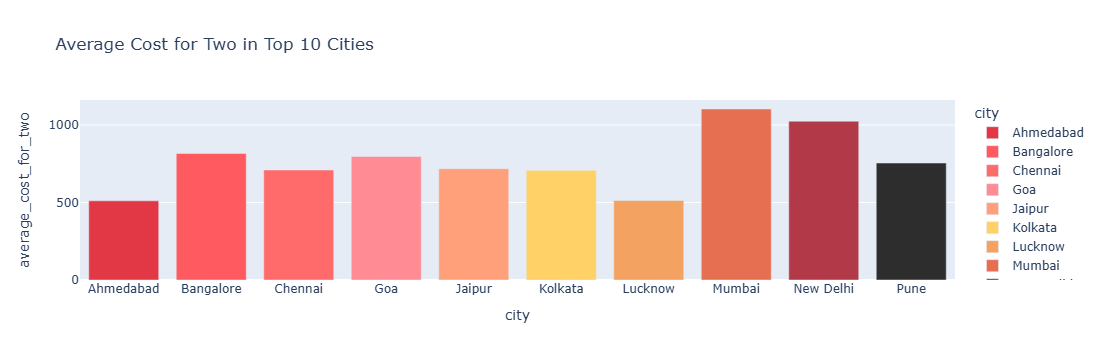

In [73]:
top_10_cities = df['city'].value_counts().head(10).index
city_cost = df[df['city'].isin(top_10_cities)].groupby('city')['average_cost_for_two'].mean().reset_index()

palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']

fig = px.bar(
    city_cost,              
    x='city', 
    y='average_cost_for_two',
    title='Average Cost for Two in Top 10 Cities',
    color='city',          
    color_discrete_sequence=palette)

fig.show()


* Mumbai has the highest average cost for two, clearly dominating all other cities.
* High costs in Mumbai are driven by premium dining density, high rentals, and strong purchasing power.
* Bangalore, Goa, and Pune form a mid-tier cluster with relatively high but balanced dining costs.
* These cities reflect strong demand from young professionals and tourism-driven consumption patterns.
* Ahmedabad and Lucknow show the lowest average cost among the top 10 cities.
* Lower costs in these cities indicate higher presence of budget-friendly and street food outlets.
* Chennai, Jaipur, and Kolkata display similar average cost levels, showing structural uniformity.
* Despite geographic differences, these cities maintain a balanced mix of restaurant types.
* Mumbai shows high average cost but not necessarily the highest restaurant count.
* This indicates a premium-heavy market structure rather than volume-driven growth.
* Tier-2 cities contribute to affordability-driven dining ecosystems.
* Tier-1 cities show a mix of premium and casual dining, increasing average cost variability.
* Overall trend shows clear segmentation of cities into premium, mid-range, and budget clusters.


In [74]:
# Online Delivery vs Rating

plot_data = df[df['aggregate_rating'] > 0].copy()

plot_data['delivery_status'] = plot_data['delivery'].map({1: 'Offers Delivery', 0: 'No Delivery'})

palette = ['#E23744', '#7A1020']

fig = px.bar(
    plot_data.groupby('delivery_status')['aggregate_rating'].mean().reset_index(), 
    x='delivery_status', 
    y='aggregate_rating',
    color='delivery_status', 
    color_discrete_sequence=palette,
    title='Average Rating by Delivery Status',
    labels={'delivery_status': 'Delivery Availability', 'aggregate_rating': 'Average Rating'})

fig.update_layout(showlegend=False)
fig.show()


* Restaurants offering delivery have a slightly higher average rating (~3.5) than non-delivery restaurants (~3.2).
* The difference is small but indicates delivery contributes positively to customer satisfaction.
* Convenience plays a role in improving customer experience in urban dining behavior.
* In Budget segment (Price Range 1), delivery has almost no impact on rating distribution.
* Budget customers focus more on food quality and price rather than delivery availability.
* In Mid-range segments (Price Range 2 & 3), delivery restaurants show higher and more stable ratings.
* Delivery acts as a competitive advantage for mid-range restaurants targeting working professionals.
* Mid-range delivery-enabled restaurants show tighter rating distributions, indicating consistency.
* In Premium segment (Price Range 4), delivery has minimal impact on ratings.
* High-end dining ratings are driven mainly by in-restaurant experience rather than delivery.
* The overall rating boost from delivery is marginal but more noticeable in mid-tier categories.
* Many restaurants still do not offer delivery, indicating untapped potential in the dataset.
* Expanding delivery services could help improve engagement and rating stability in mid-range restaurants.
* Overall, delivery improves ratings slightly but its impact depends heavily on price segment.


In [75]:
# establishment vs Rating

In [76]:
filtered_df = df[
    (df['establishment'].isin(top_10)) & 
    (df['aggregate_rating'] > 0) & 
    (df['establishment'].apply(lambda x: x != "[]" and x != ""))]
palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48']
fig = px.box(
    filtered_df, 
    x='establishment', 
    y='aggregate_rating', 
    title='Rating by Establishment Type',
    color='establishment', 
    color_discrete_sequence=palette)
fig.show()

NameError: name 'top_10' is not defined


* Fine Dining has the highest median rating, close to 4.0, indicating premium and consistent quality.
* Fine Dining also shows the smallest spread, meaning ratings are highly stable with low variation.
* Casual Dining and Cafés show similar median ratings (~3.7), indicating balanced and reliable performance.
* These categories act as “safe choices” for customers due to consistent experience levels.
* Quick Bites shows the widest rating distribution, indicating highly inconsistent quality.
* Quick Bites includes both very low and moderately high ratings, reflecting uneven service quality.
* High variability in Quick Bites is due to volume-driven operations and limited quality control.
* Dessert Parlours show relatively high and stable ratings due to specialization in limited menu items.
* Beverage Shops also maintain consistent ratings because of focused product offerings.
* Food Courts have lower median ratings and wider spread, indicating average overall performance.
* Food Courts are more convenience-driven rather than experience-driven, affecting ratings.
* Premium formats generally show higher rating stability compared to budget-oriented formats.
* Establishment type strongly influences rating consistency more than just price range.
* Overall, specialized and premium formats perform better in both consistency and customer satisfaction.


In [ ]:
# Photo Count vs Rating

In [ ]:
top_10_cuisines = df['primary_cuisine'].value_counts().head(10).index

cuisine_price = df[df['primary_cuisine'].isin(top_10_cuisines)].copy()
cuisine_price['price_range'] = cuisine_price['price_range'].astype(str)

palette = ['#FFCDD2', '#E23744', '#B71C1C', '#4A0D12']

fig = px.histogram(
    cuisine_price, 
    x='primary_cuisine', 
    color='price_range',
    color_discrete_sequence=palette,
    title='Cuisine Distribution across Price Ranges',
    barmode='group', 
    category_orders={"primary_cuisine": top_10_cuisines} )

fig.update_layout(xaxis_title="Cuisine Type", yaxis_title="Number of Restaurants")
fig.show()


* Photo count shows a strong positive correlation with votes (~0.68), indicating high visual engagement drives popularity.
* Restaurants with more photos attract significantly more customer interaction and visibility.
* Photo-rich listings act as strong social proof, increasing user trust and click-through behavior.
* Photo count has a weak positive correlation with rating (~0.23), showing limited direct impact on food quality perception.
* This implies visuals attract customers but do not guarantee higher satisfaction scores.
* Customers still rate restaurants mainly based on food quality, service, and experience.
* Photo count has a moderate correlation with cost (~0.33), suggesting higher-end restaurants tend to invest more in presentation.
* Visual appeal strongly influences discovery but not necessarily final rating outcomes.
* High engagement (votes) is more driven by marketing visibility than intrinsic quality alone.
* Photos reduce perceived risk for new customers by providing expectation clarity.
* Ambiance and presentation significantly contribute to higher photo counts.
* Ratings remain relatively independent of visual marketing, reflecting real service performance.
* Overall, photo count is a strong driver of popularity but a weak predictor of quality.
* Data confirms a clear separation between “attraction factors” (photos, visibility) and “quality factors” (ratings).


In [ ]:
# Top Cuisines (Top 10) vs Price Range

top_10_names = df['primary_cuisine'].value_counts().head(10).index

cuisine_stats = df[df['primary_cuisine'].isin(top_10_names)].groupby('primary_cuisine')['price_range'].mean().reset_index()

palette = ['#E23744', '#FF5A5F', '#FF6B6B', '#FF8C94', '#FFA07A', '#FFD166', '#F4A261', '#E76F51', '#B23A48', '#2D2D2D']


fig = px.bar(
    cuisine_stats, 
    x='primary_cuisine', 
    y='price_range',
    color='primary_cuisine',
    color_discrete_sequence=palette,
    title='correlation between Price Range and Cuisine',)

fig.update_layout(xaxis={'categoryorder':'total descending'})
fig.show()


* North Indian, Café, and Chinese cuisines have the highest average price range (~2.0), indicating premium positioning.
* These cuisines are associated with full-service dining and higher operational costs, leading to higher pricing.
* South Indian cuisine sits in the mid-range (~1.5), reflecting a mix of premium restaurants and affordable tiffin centers.
* The variation in South Indian pricing shows a balanced market with both budget and premium demand.
* Bakery, Beverages, Desserts, and Fast Food cluster in the lower-mid range (1.2–1.3).
* These categories are typically low-cost, quick-service formats with limited menu complexity.
* Mithai and Street Food have the lowest price range, confirming their budget-friendly nature.
* These categories dominate the mass market due to high affordability and accessibility.
* Premium cuisines generally involve higher service levels and more complex dining experiences.
* Affordable cuisines rely on high volume and low-margin sales models.
* North Indian cuisine is both highly popular and relatively expensive, showing strong demand even at higher prices.
* Street Food and Mithai remain consistently low-priced despite high demand.
* There is a clear segmentation between premium dining cuisines and budget snack-based categories.
* Overall, cuisine type strongly influences pricing structure and reflects customer willingness to pay.


## multivariate analysis

In [ ]:
corr = df[['aggregate_rating', 'votes', 'price_range', 'average_cost_for_two','photo_count']].corr()
palette = ['#E23744', '#7A1020']
fig = px.imshow(corr,text_auto='.2f',color_continuous_scale=palette,aspect='auto',title='Correlation Heatmap of Restaurant Features')
fig.show()


* The strongest correlation is between price range and average cost for two (~0.79), confirming correct price tier structuring.
* Higher price ranges directly reflect higher actual dining costs, showing strong data consistency.
* Photo count and votes show a strong positive correlation (~0.68), indicating visuals strongly drive engagement.
* Restaurants with more photos tend to receive significantly higher customer interaction and visibility.
* Aggregate rating has weak correlation with votes (~0.28), showing popularity is not strongly tied to rating.
* Aggregate rating also shows weak correlation with price range (~0.26), meaning expensive food does not guarantee better ratings.
* Rating vs photo count correlation (~0.23) is weak, proving visuals attract users but don’t define quality.
* Cost-related variables show moderate correlation with photo count (~0.30–0.33), indicating premium places invest more in presentation.
* Votes and cost have low correlation (~0.26–0.27), meaning both budget and premium restaurants can be equally popular.
* Popularity is distributed across all price segments rather than being concentrated in high-cost restaurants.
* Quality (rating) appears largely independent of marketing and pricing factors.
* Engagement (votes) is more influenced by visibility and visuals than by actual pricing.
* The dataset shows a clear separation between engagement drivers (photos, visibility) and quality drivers (service, food).
* Overall, visuals drive discovery, while experience drives ratings, and price does not strongly control either.


In [ ]:
fig = px.box(df[df['aggregate_rating'] > 0], x='price_range', y='aggregate_rating',color_discrete_sequence= ['#E23744', '#2D2D2D'], color='delivery',title='Rating Distribution across Price and Delivery')

fig.show()


* Restaurants offering delivery generally show higher median ratings across all price ranges.
* Delivery-enabled restaurants also have tighter distributions, indicating more consistent customer satisfaction.
* Delivery acts as a stabilizing factor, reducing rating variability across segments.
* In Price Range 1, delivery slightly improves consistency but has limited impact on median rating.
* Budget restaurants without delivery show higher volatility and more low-rating outliers.
* Price Range 3 shows the strongest difference between delivery and non-delivery restaurants.
* Mid-to-high segment restaurants benefit most from delivery in terms of rating improvement.
* In higher price ranges, delivery helps maintain ratings above a stable threshold (~3.5+).
* Higher-priced restaurants generally achieve better ratings regardless of delivery status.
* Delivery enhances customer satisfaction by improving convenience and service accessibility.
* Non-delivery restaurants tend to have wider rating spread and lower reliability.
* Delivery availability reduces extreme negative ratings, improving overall experience perception.
* The combined effect shows price sets the baseline, while delivery improves consistency.
* Overall, delivery positively influences ratings, especially in mid-range restaurant segments.


In [ ]:
fig = px.scatter_mapbox(
    df[df['aggregate_rating'] > 0], 
    lat="latitude", 
    lon="longitude", 
    color="aggregate_rating", 
    size="votes",               
    hover_name="name", 
    zoom=4, 
    center={"lat": 22.5, "lon": 78.9}, 
    mapbox_style="carto-positron", 
    color_continuous_scale=['#FFB3B3', '#8B0000'],
    title="High-Density Restaurant Hubs in India")

fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

## **EDA Insights: Geospatial Restaurant Distribution (Mapbox Visualization)**

* The map represents restaurant locations across India using latitude and longitude coordinates.
* Color intensity (red scale) represents aggregate rating, with darker red indicating higher ratings.
* Bubble size represents votes, indicating restaurant popularity and customer engagement.
* The visualization combines geography, quality, and popularity into a single multivariate view.
* High-density clusters appear in Tier-1 cities like Mumbai, Delhi-NCR, Bangalore, and Pune.
* South Indian metros show especially strong concentration of restaurants, indicating a mature market.
* Urban regions dominate the dataset, reflecting higher digital adoption and food delivery penetration.
* Central India shows relatively sparse restaurant distribution, indicating lower platform penetration.
* Large dark-red bubbles indicate high-rated, highly popular “market leader” restaurants.
* Large light-colored bubbles indicate high popularity but lower rating (“hype hubs”).
* Some small but dark red points represent niche high-quality restaurants with lower visibility.
* Remote locations like Gangtok show lower density but still maintain active restaurant listings.
* This indicates Zomato usage extends beyond metros into tourist and regional markets.
* Competition is highest in metro clusters, leading to more variation in ratings and engagement.
* Smaller cities show fewer restaurants but more uniform rating patterns.
* Overall, the map highlights a clear urban dominance in both quality and engagement metrics.
* The visualization effectively shows how popularity (votes) and quality (ratings) vary geographically.
* It acts as a “success distribution map” of restaurants across India.


## **EDA Project Summary: Zomato Indian Restaurant Analysis**

* The project explores India’s restaurant ecosystem using data cleaning, visualization, and geospatial analysis.
* Libraries like pandas, seaborn, and plotly are used to analyze trends in cuisine, pricing, ratings, and geography.
* North Indian cuisine is the most dominant (~32.9%), followed by Fast Food and Bakery, showing strong demand for familiar and quick-service food.
* Tier-1 cities like Chennai, Mumbai, and Bangalore have the highest restaurant concentration, indicating strong Zomato penetration.
* Budget restaurants (Price Range 1) dominate the market, reflecting India’s price-sensitive consumer base.
* Restaurants offering delivery show slightly better and more stable ratings compared to dine-in-only outlets.
* Photo count has a strong correlation with votes (~0.68), making visuals a key driver of engagement.
* Price range has a weak correlation with rating (~0.26), showing that cost does not strongly determine quality perception.
* Customer ratings are more influenced by experience than by pricing structure.
* Geospatial analysis reveals dense restaurant clusters in metro regions forming the “Golden Quadrilateral” belt.
* Central India shows comparatively lower restaurant density, indicating untapped market potential.
* Map-based analysis distinguishes between “Market Leaders” (high rating + high votes) and “Hype Hubs” (low rating + high votes).
* Data cleaning removes incorrect coordinates to ensure accurate India-focused visualization.
* Delivery and visual content act as major engagement drivers across the platform.
* Overall, the market is highly urban-centric, competitive, and driven by experience rather than price alone.


## **Actionable EDA Insights: Zomato Project Recommendations**

### **1. Recommendations for Restaurant Owners (Growth Strategy)**

* Improve photo count and quality since visuals strongly drive engagement (votes correlation ~0.68).
* Use high-quality food and ambiance images to increase visibility and customer trust.
* Enable delivery services to improve rating consistency and reduce customer dissatisfaction.
* Focus on mid-price segments (Price Range 2–3) to balance demand and competition effectively.
* Avoid competing only in low-price saturated segments like budget North Indian outlets.
* Improve operational consistency (service speed, food quality) to convert high votes into higher ratings.
* Monitor “high votes but low rating” patterns as indicators of operational inefficiencies.
* Invest in experience quality rather than only marketing, since rating is weakly tied to price (~0.26).
* Target cities with high density but moderate competition for better growth opportunities.
* Use delivery + dine-in hybrid models to maximize engagement and rating stability.

---

### **2. Recommendations for Users (Smart Decision-Making)**

* Prefer restaurants with high ratings but moderate vote counts to find better quality “hidden gems.”
* Do not rely on price as a quality indicator since correlation with rating is weak.
* Use photo-rich listings as a trust indicator for transparency and food expectations.
* Consider delivery-enabled restaurants for more consistent service quality.
* Look for mid-range restaurants (Price Range 2–3) for best value-for-money experiences.
* Avoid choosing purely based on popularity since high votes do not guarantee high quality.
* Use rating range (4.0–4.5) combined with moderate pricing for optimal dining choices.
* Analyze review distribution rather than just average rating for better decision-making.
* Explore less crowded, highly rated places for better experience and service speed.
* Treat visuals and consistency together as better indicators than price alone.

## Conclusion 

* The Indian restaurant market is highly **urban-centric and competitive**, with major clusters in Tier-1 cities like Mumbai, Bangalore, and Delhi.
* **Visual content (photo count)** is the strongest driver of engagement, showing a high correlation with votes (~0.68), making visibility a key success factor.
* There is a **weak relationship between price and rating (~0.26)**, indicating that quality perception is independent of cost and reflects a value-driven market.
* **Delivery services improve rating stability**, acting as a buffer that enhances consistency in customer experience.
* Geospatial analysis reveals strong metro dominance and highlights **untapped growth potential in Tier-2 and central regions of India**.
* Overall success on Zomato depends on balancing **visibility (photos), accessibility (delivery), and quality (ratings)** rather than price alone.
